### This project is about analyzing student performance data, where we will use `KNN Regression` to predict students’ GPA based on their demographics, study habits, and extracurricular activities.

## Import required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### The dataset we are having is `Student_performance_data.csv` using pandas import it

In [3]:
df = pd.read_csv('Student_performance_data.csv')

### View the top 5 rows of the dataset

In [4]:
df.head(10)

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
5,1006,18,0,0,1,8.191219,0,0,1,1,0,0,0,3.084184,1.0
6,1007,15,0,1,1,15.601680,10,0,3,0,1,0,0,2.748237,2.0
7,1008,15,1,1,4,15.424496,22,1,1,1,0,0,0,1.360143,4.0
8,1009,17,0,0,0,4.562008,1,0,2,0,1,0,1,2.896819,2.0
9,1010,16,1,0,1,18.444466,0,0,3,1,0,0,0,3.573474,0.0


In [51]:
df.columns

Index(['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly',
       'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports',
       'Music', 'Volunteering', 'GPA', 'GradeClass'],
      dtype='object')

### Let’s explore the dataset to see the data types of each column. we  will use `.info()` for this

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


### Check for total null values present in the dataset

In [6]:
df.isnull().sum()

,0
StudentID,0
Age,0
Gender,0
Ethnicity,0
ParentalEducation,0
StudyTimeWeekly,0
Absences,0
Tutoring,0
ParentalSupport,0
Extracurricular,0


### The ‘StudentID’ column does not contribute to our analysis, so we can drop it.

In [7]:
df.drop('StudentID',axis=1,inplace=True)

In [8]:
df.shape

(2392, 14)

In [9]:
df.describe()

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


### Visualization

### Plotting the GPA distribution to visualize how students’ academic performance is spread across the dataset `histplot()`.

<Axes: xlabel='GPA', ylabel='Count'>

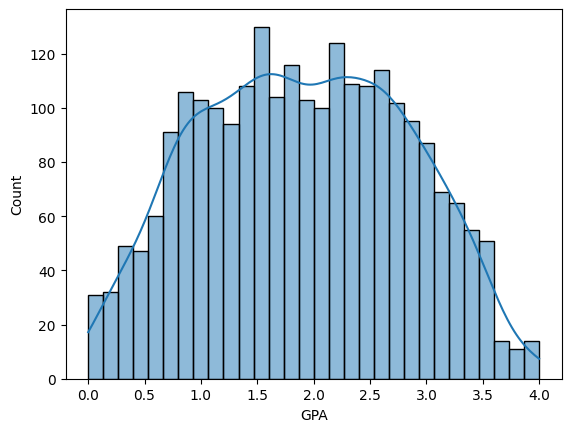

In [11]:
sns.histplot(x=df['GPA'],bins=30,kde=True)

### Let’s plot a scatter plot to see how study time affects GPA, with colors showing different grade classes `scatterplot()`.

<Axes: xlabel='StudyTimeWeekly', ylabel='GPA'>

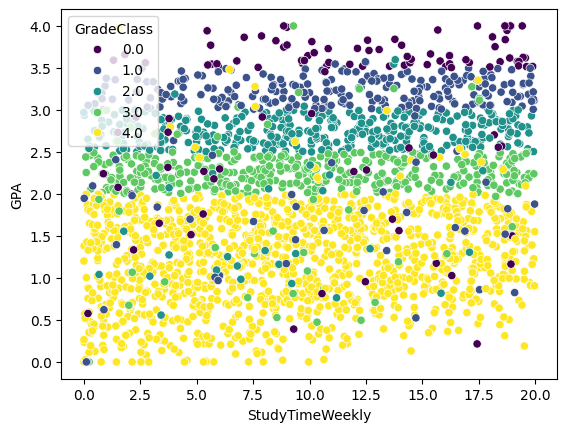

In [14]:
sns.scatterplot(x=df['StudyTimeWeekly'],y=df['GPA'],hue=df['GradeClass'],palette='viridis')

### Visualize how students' absences relate to their GPA using a scatter plot, and see the difference across grade classes `.scatterplot()`

<Axes: xlabel='Absences', ylabel='GPA'>

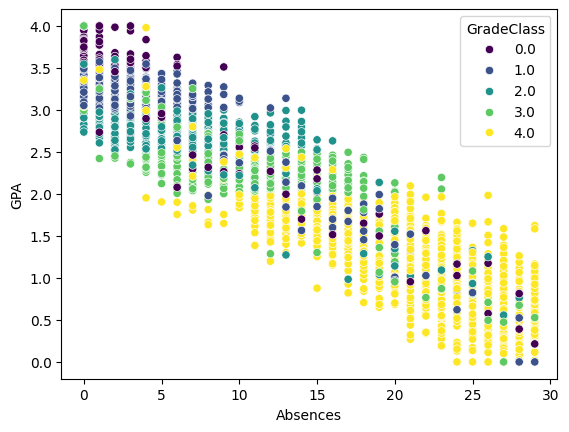

In [18]:
sns.scatterplot(data=df, x='Absences',y='GPA',hue='GradeClass', palette='viridis')

### Let's plot a heatmap to visualize how all numerical features in the dataset are correlated with each other

<Axes: >

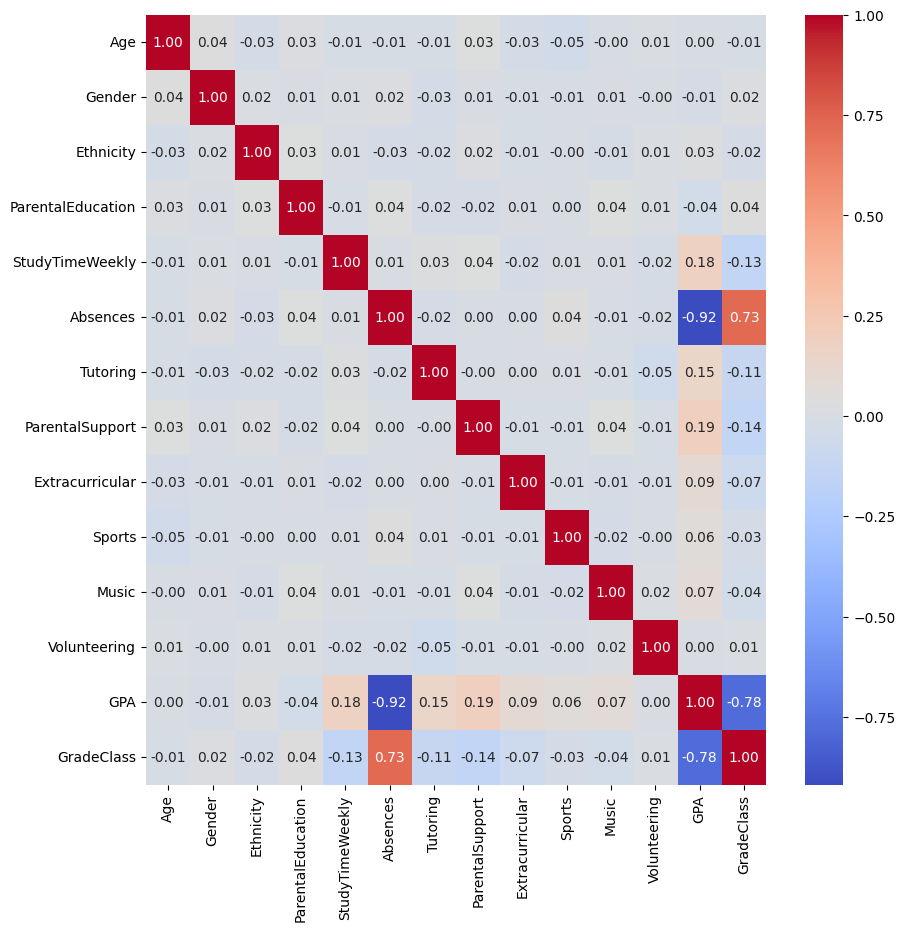

In [20]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

# Task
Analyze the dataset to identify variables significantly influencing 'GPA'. This involves:
1.  **Identifying Variable Types**: Categorize features as numerical or categorical (excluding 'GPA' and 'GradeClass').
2.  **Pearson Correlation**: Calculate Pearson correlation coefficients and p-values for numerical features against 'GPA'.
3.  **ANOVA Test**: Perform ANOVA tests for categorical features against 'GPA'.
4.  **Present Results**: Display the statistical test results.
5.  **Visualizations**: Create scatter plots for numerical features vs 'GPA' and box plots for categorical features vs 'GPA'.
6.  **Summarize Findings**: Conclude which variables have a significant relationship with 'GPA'.

## Identify Variable Types

### Subtask:
Programmatically identify and categorize columns in the DataFrame as numerical or categorical, excluding 'GPA' and 'GradeClass'.


**Reasoning**:
I need to programmatically identify and categorize columns into numerical and categorical features as per the instructions, excluding 'GPA' and 'GradeClass'. I will create two lists and then print them.



In [21]:
numerical_features = ['Age', 'StudyTimeWeekly', 'Absences']
categorical_features = ['Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['Age', 'StudyTimeWeekly', 'Absences']
Categorical Features: ['Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']


## Perform Pearson Correlation for Numerical Features

### Subtask:
For each numerical feature, calculate the Pearson correlation coefficient and its corresponding p-value with 'GPA'. This test will quantify the linear relationship between numerical variables and student performance.


**Reasoning**:
To perform Pearson correlation tests, I need to import the `pearsonr` function from `scipy.stats`. This is the first step required by the instructions.



In [22]:
from scipy.stats import pearsonr

**Reasoning**:
Now that `pearsonr` is imported, I will iterate through the `numerical_features` list, calculate the Pearson correlation coefficient and p-value for each feature against 'GPA', store these results, and then print them as specified in the instructions.



In [23]:
correlation_results = {}
for feature in numerical_features:
    correlation, p_value = pearsonr(df[feature], df['GPA'])
    correlation_results[feature] = {'correlation': correlation, 'p_value': p_value}

for feature, results in correlation_results.items():
    print(f"Feature: {feature}\n  Pearson Correlation: {results['correlation']:.4f}\n  P-value: {results['p_value']:.4f}\n")

Feature: Age
  Pearson Correlation: 0.0003
  P-value: 0.9893

Feature: StudyTimeWeekly
  Pearson Correlation: 0.1793
  P-value: 0.0000

Feature: Absences
  Pearson Correlation: -0.9193
  P-value: 0.0000



**Reasoning**:
To perform ANOVA tests for categorical features, I need to import the `f_oneway` function from `scipy.stats`.



In [24]:
from scipy.stats import f_oneway

**Reasoning**:
Now that `f_oneway` is imported, I will iterate through the `categorical_features` list, perform an ANOVA test for each feature against 'GPA', store the F-statistic and p-value, and then print these results as specified in the instructions.



In [25]:
anova_results = {}
for feature in categorical_features:
    groups = [df['GPA'][df[feature] == category] for category in df[feature].unique()]
    f_statistic, p_value = f_oneway(*groups)
    anova_results[feature] = {'f_statistic': f_statistic, 'p_value': p_value}

for feature, results in anova_results.items():
    print(f"Feature: {feature}\n  F-statistic: {results['f_statistic']:.4f}\n  P-value: {results['p_value']:.4f}\n")

Feature: Gender
  F-statistic: 0.4267
  P-value: 0.5137

Feature: Ethnicity
  F-statistic: 0.9581
  P-value: 0.4116

Feature: ParentalEducation
  F-statistic: 1.8081
  P-value: 0.1245

Feature: Tutoring
  F-statistic: 51.4150
  P-value: 0.0000

Feature: ParentalSupport
  F-statistic: 22.7235
  P-value: 0.0000

Feature: Extracurricular
  F-statistic: 21.3421
  P-value: 0.0000

Feature: Sports
  F-statistic: 8.0278
  P-value: 0.0046

Feature: Music
  F-statistic: 12.9169
  P-value: 0.0003

Feature: Volunteering
  F-statistic: 0.0254
  P-value: 0.8735



**Reasoning**:
I need to create scatter plots for each numerical feature against 'GPA' to visualize their relationships as per the main task. I will iterate through the `numerical_features` list and generate a scatter plot for each feature.



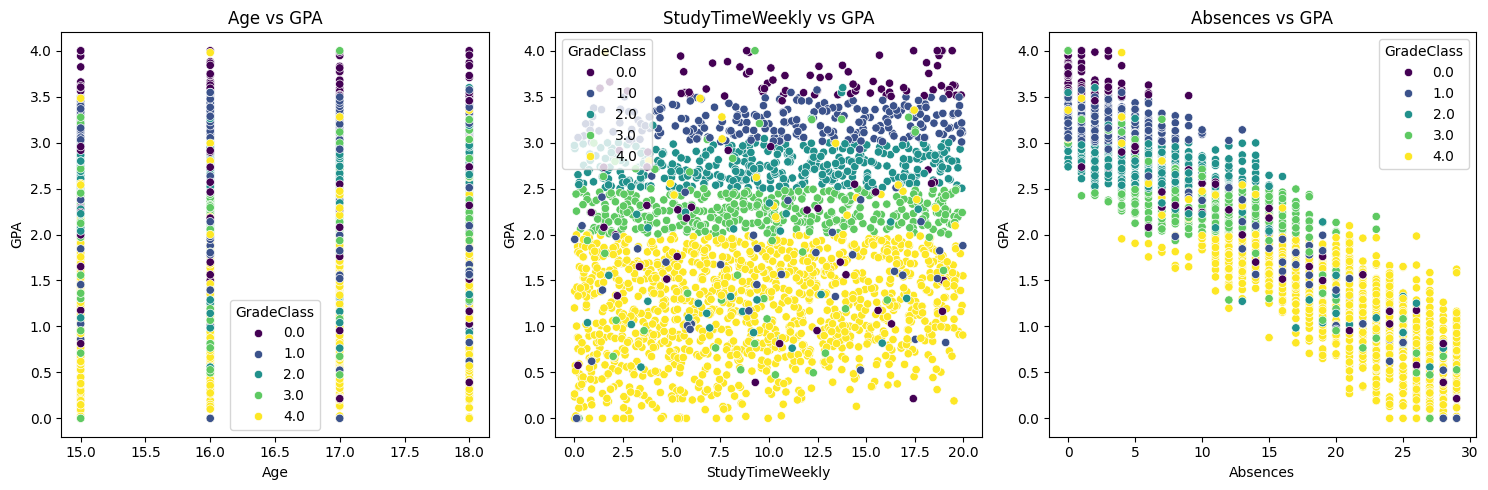

In [26]:
plt.figure(figsize=(15, 5))
for i, feature in enumerate(numerical_features):
    plt.subplot(1, len(numerical_features), i + 1)
    sns.scatterplot(x=df[feature], y=df['GPA'], hue=df['GradeClass'], palette='viridis')
    plt.title(f'{feature} vs GPA')
    plt.xlabel(feature)
    plt.ylabel('GPA')
plt.tight_layout()
plt.show()

**Reasoning**:
I need to create box plots for each categorical feature against 'GPA' to visualize their relationships as per the main task. I will iterate through the `categorical_features` list and generate a box plot for each feature.



/tmp/ipython-input-187/1393071101.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[feature], y=df['GPA'], palette='viridis')
/tmp/ipython-input-187/1393071101.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[feature], y=df['GPA'], palette='viridis')
/tmp/ipython-input-187/1393071101.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[feature], y=df['GPA'], palette='viridis')
/tmp/ipython-input-187/1393071101.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Ass

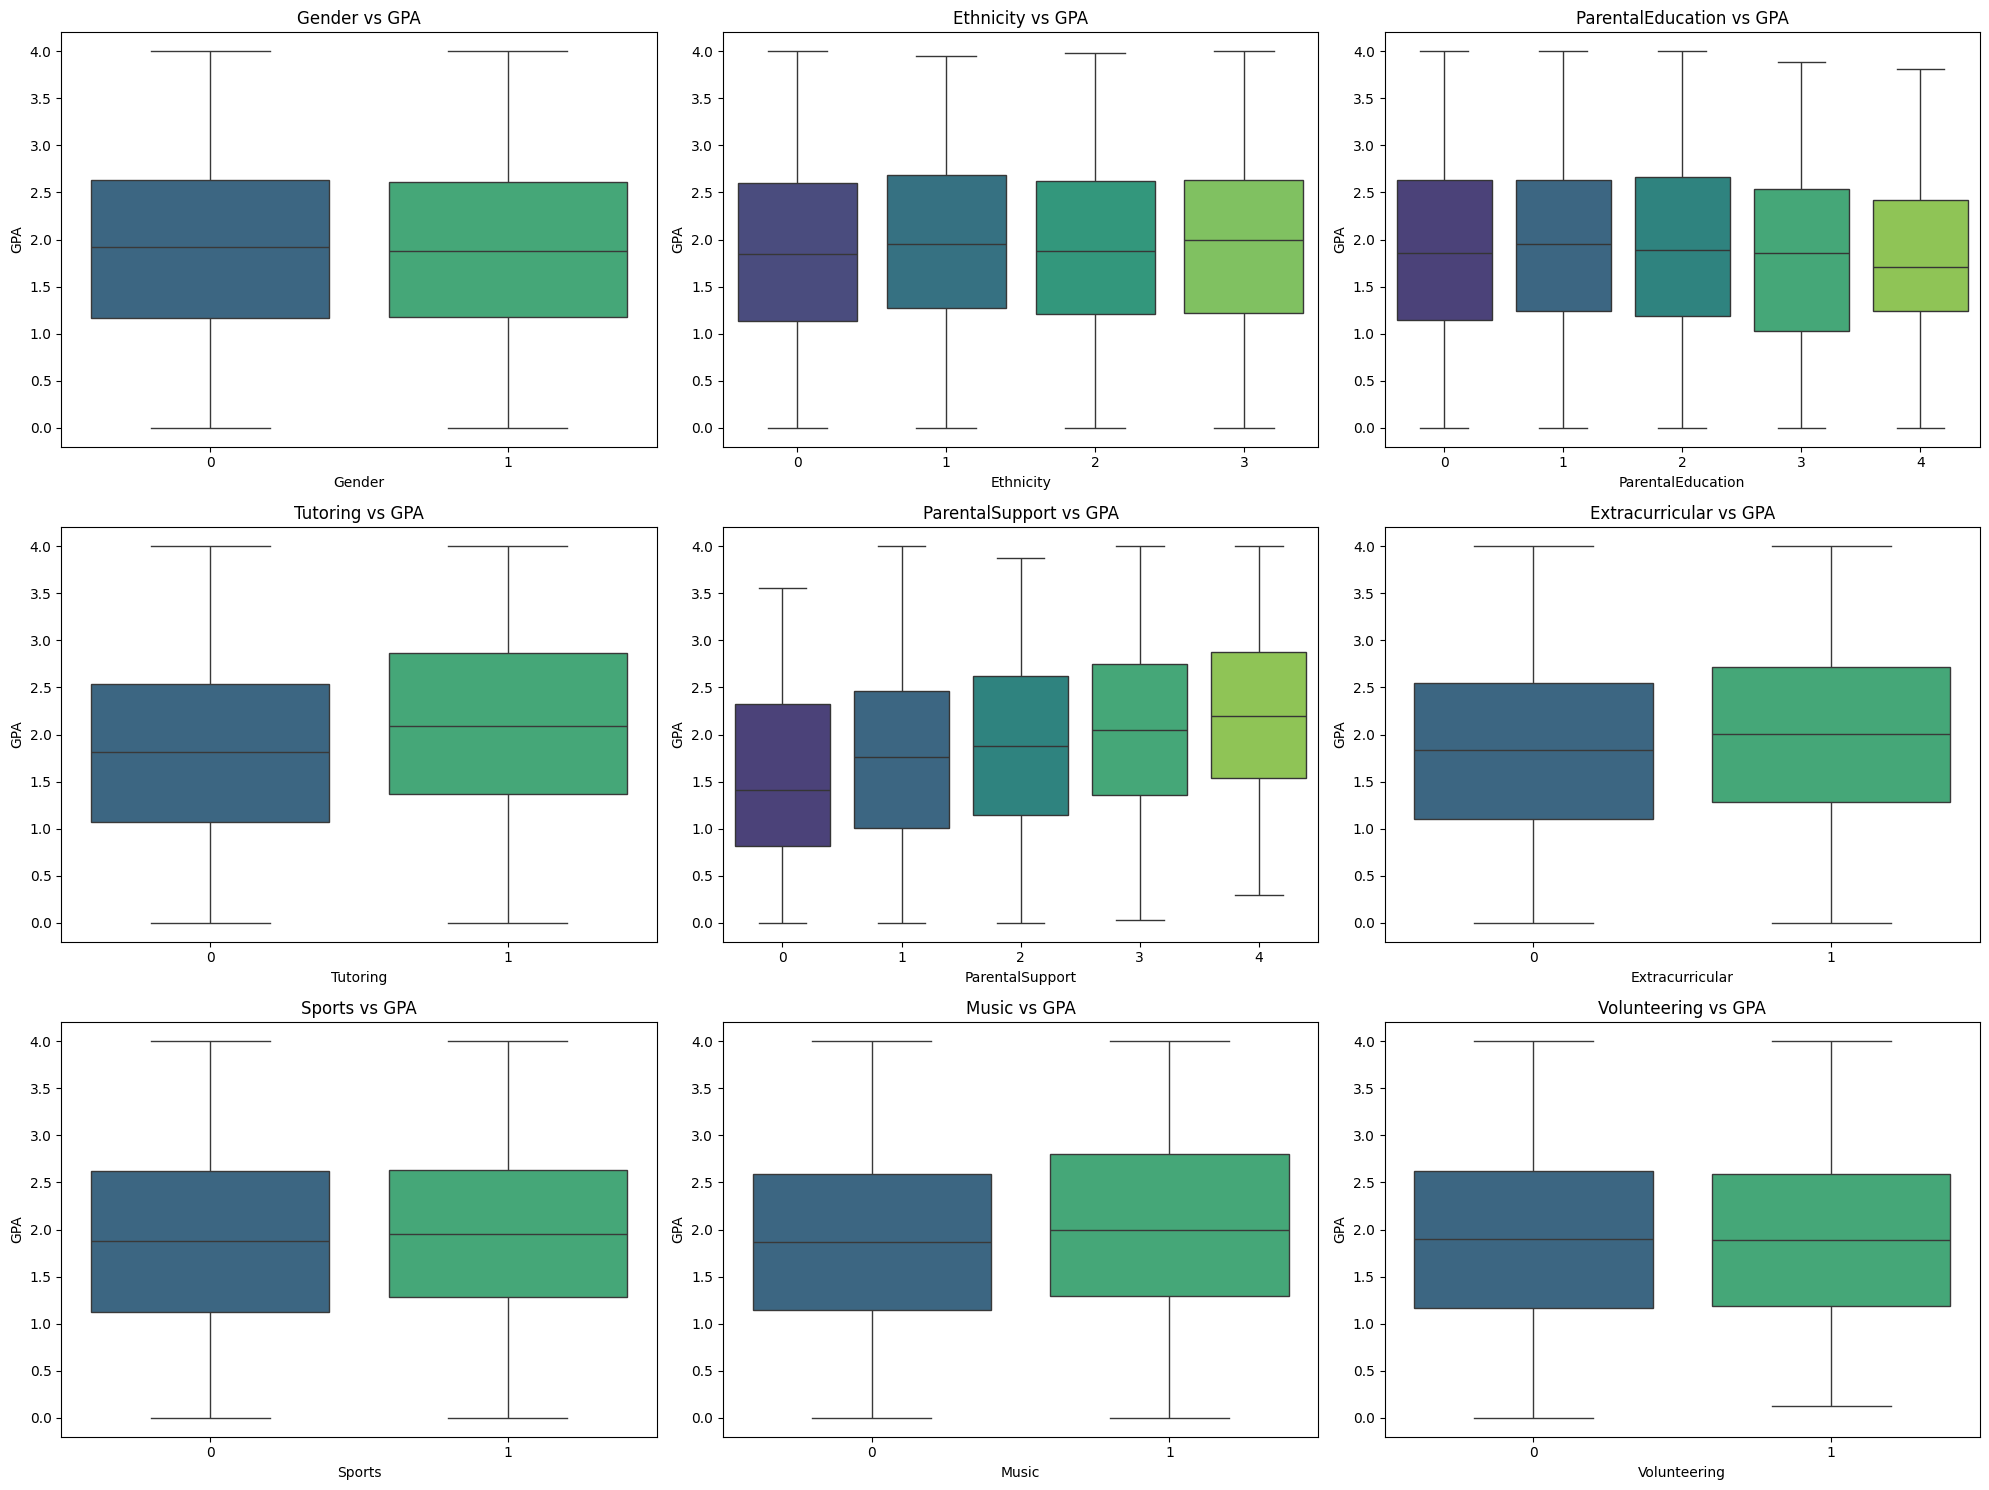

In [27]:
plt.figure(figsize=(20, 15))
for i, feature in enumerate(categorical_features):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of categorical features
    sns.boxplot(x=df[feature], y=df['GPA'], palette='viridis')
    plt.title(f'{feature} vs GPA')
    plt.xlabel(feature)
    plt.ylabel('GPA')
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` because `palette` was used without `hue` in `sns.boxplot`. To address this, I will explicitly assign the `x` variable to `hue` and set `legend=False` in the `sns.boxplot` call, as recommended by the warning, to ensure future compatibility and suppress the warning.



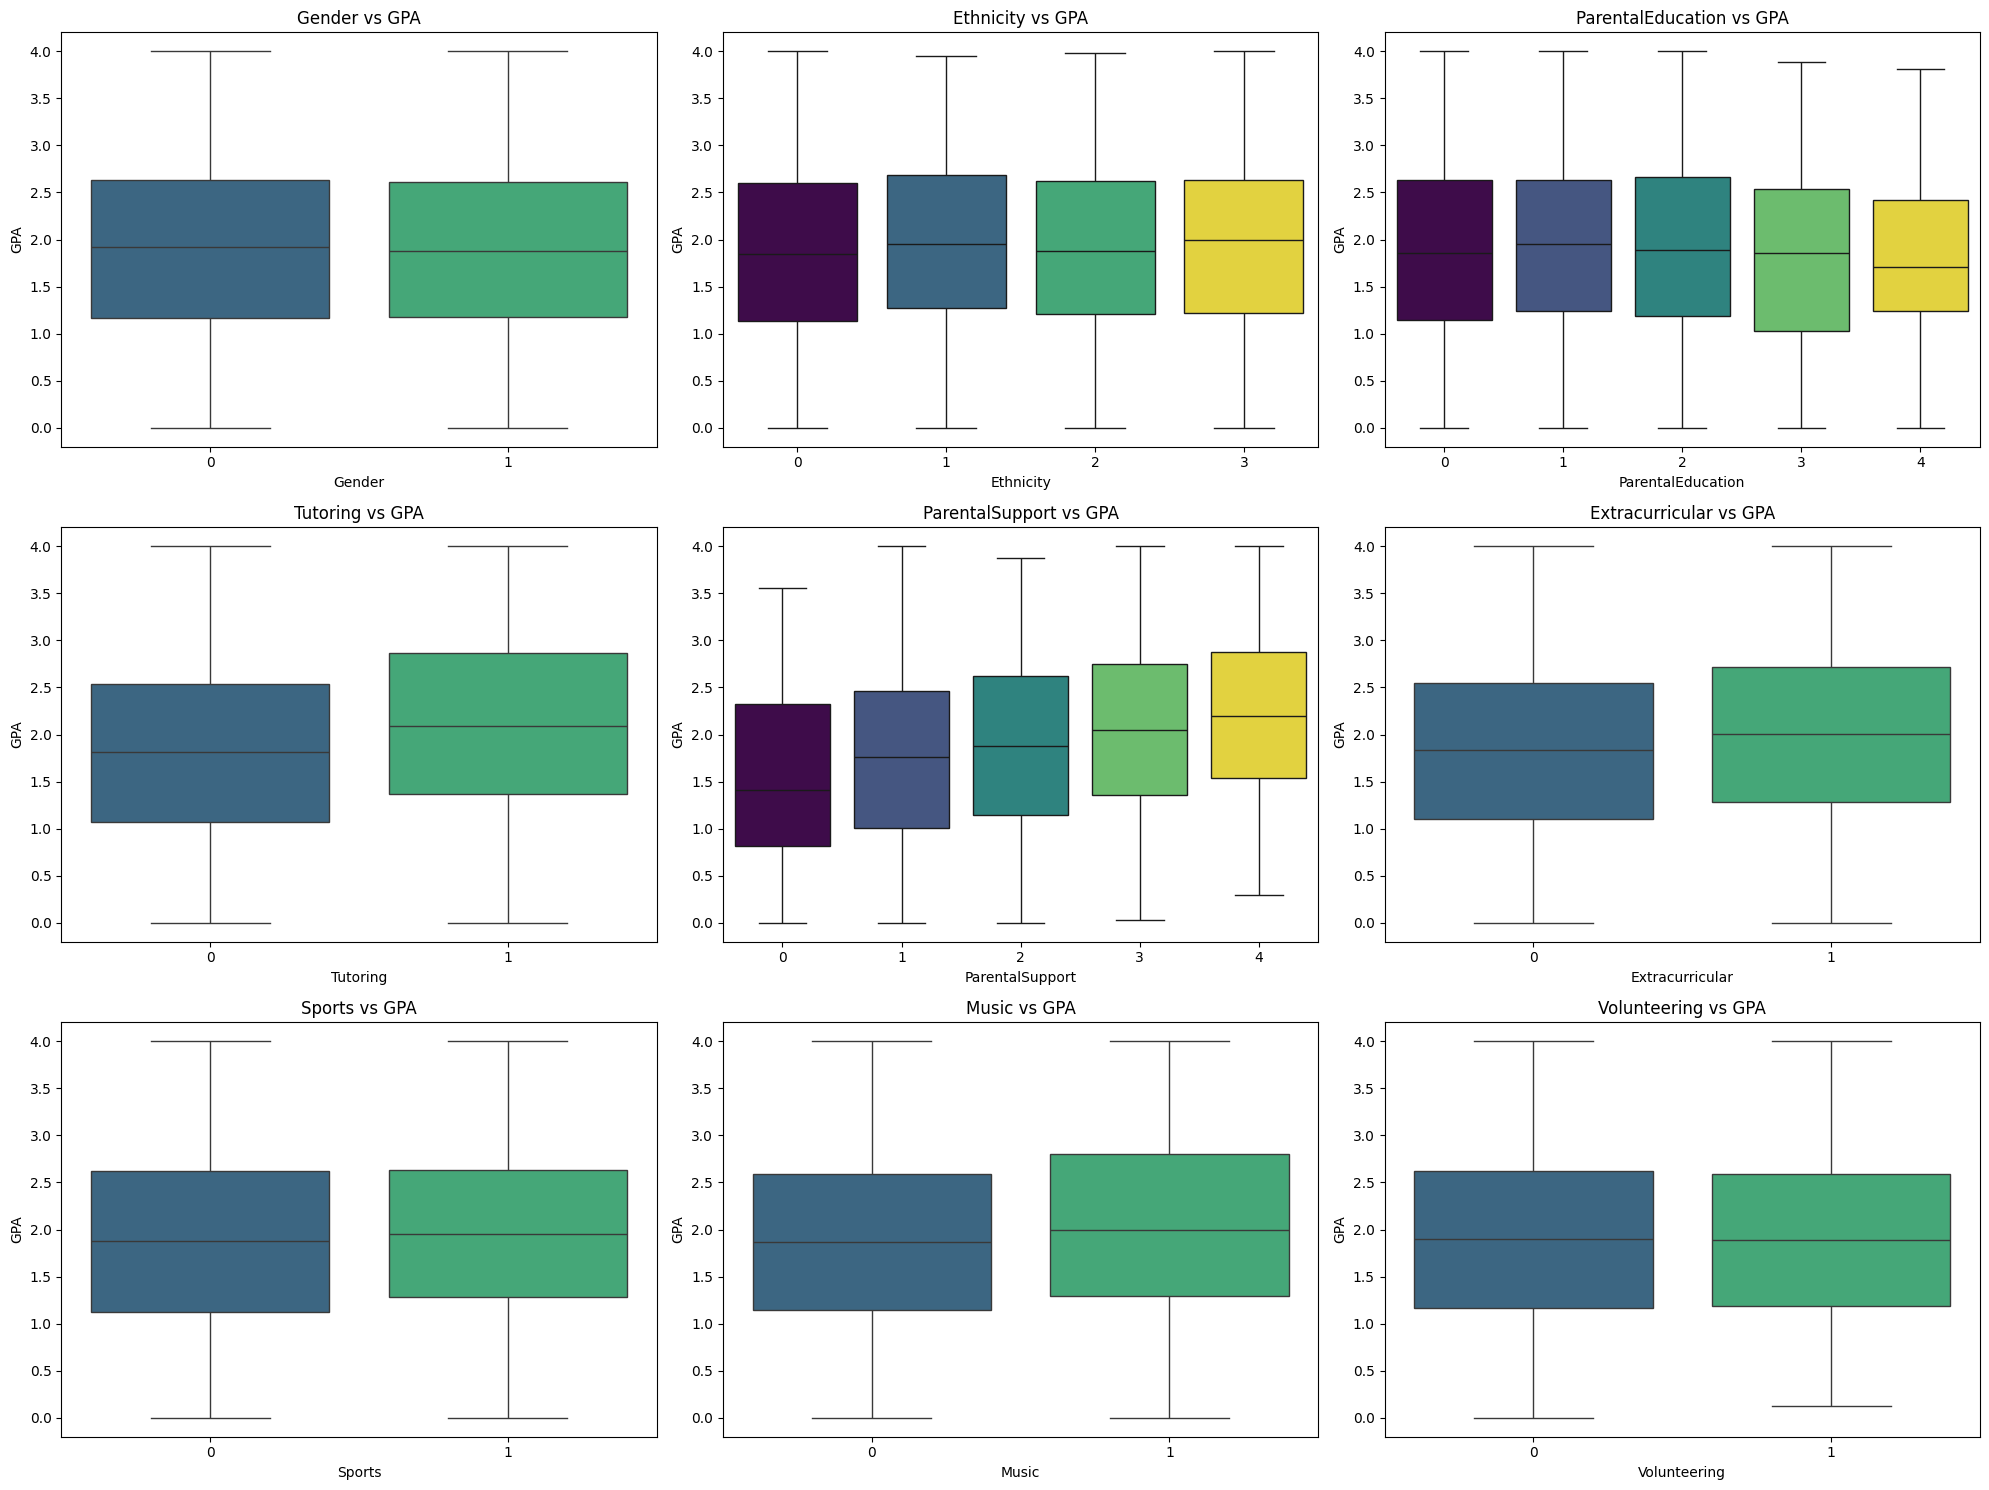

In [28]:
plt.figure(figsize=(20, 15))
for i, feature in enumerate(categorical_features):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of categorical features
    sns.boxplot(x=df[feature], y=df['GPA'], hue=df[feature], palette='viridis', legend=False)
    plt.title(f'{feature} vs GPA')
    plt.xlabel(feature)
    plt.ylabel('GPA')
plt.tight_layout()
plt.show()

## Summarize Findings

Based on the Pearson Correlation and ANOVA test results, along with the visualizations, we can identify the following variables as significantly influencing 'GPA':

### Numerical Features:

*   **StudyTimeWeekly**: With a Pearson correlation coefficient of **0.1793** and a **p-value of 0.0000**, 'StudyTimeWeekly' shows a statistically significant positive linear relationship with 'GPA'. This is visually supported by the scatter plot, which generally indicates that students who spend more time studying tend to have higher GPAs.

*   **Absences**: 'Absences' has a strong negative Pearson correlation of **-0.9193** and a **p-value of 0.0000**, indicating a highly significant inverse relationship with 'GPA'. The scatter plot clearly illustrates this, showing that as the number of absences increases, GPA tends to decrease sharply.

*   **Age**: 'Age' has a very weak Pearson correlation of **0.0003** with a **p-value of 0.9893**. This high p-value suggests no statistically significant linear relationship between age and GPA in this dataset.

### Categorical Features:

*   **Tutoring**: The ANOVA test for 'Tutoring' yielded an F-statistic of **51.4150** and a **p-value of 0.0000**. This strongly indicates that there are significant differences in GPA between students who receive tutoring and those who don't. The box plot for 'Tutoring' further visualizes this, showing a noticeable difference in GPA distributions between the tutoring groups.

*   **ParentalSupport**: The ANOVA test for 'ParentalSupport' resulted in an F-statistic of **22.7235** and a **p-value of 0.0000**. This suggests a significant impact of parental support on GPA, with different levels of support correlating with different GPA averages. The box plot displays distinct GPA ranges for various parental support categories.

*   **Extracurricular**: 'Extracurricular' activities show a significant effect on GPA, with an F-statistic of **21.3421** and a **p-value of 0.0000**. The box plot for 'Extracurricular' visually confirms that participation (or lack thereof) in extracurricular activities is associated with differing GPA outcomes.

*   **Sports**: Involvement in 'Sports' also has a statistically significant relationship with GPA, as indicated by an F-statistic of **8.0278** and a **p-value of 0.0046**. The box plot shows variations in GPA based on sports participation.

*   **Music**: Similar to sports, 'Music' participation is significantly related to GPA, with an F-statistic of **12.9169** and a **p-value of 0.0003**. The box plot highlights different GPA distributions for students involved in music.

*   **Gender, Ethnicity, ParentalEducation, and Volunteering**: These features exhibited high p-values (0.5137, 0.4116, 0.1245, and 0.8735, respectively), suggesting that there is no statistically significant relationship between these categorical variables and 'GPA' in this dataset based on the ANOVA test. The box plots for these features show overlapping GPA distributions across categories, supporting the non-significant findings.

**Conclusion:**

The most significant factors influencing 'GPA' in this dataset are **Absences**, **StudyTimeWeekly**, **Tutoring**, **ParentalSupport**, **Extracurricular**, and **Music**. These variables demonstrate strong statistical relationships and clear visual trends with student performance.

## Summarize Findings

Based on the Pearson Correlation and ANOVA test results, along with the visualizations, we can identify the following variables as significantly influencing 'GPA':

### Numerical Features:

*   **StudyTimeWeekly**: With a Pearson correlation coefficient of **0.1793** and a **p-value of 0.0000**, 'StudyTimeWeekly' shows a statistically significant positive linear relationship with 'GPA'. This is visually supported by the scatter plot, which generally indicates that students who spend more time studying tend to have higher GPAs.

*   **Absences**: 'Absences' has a strong negative Pearson correlation of **-0.9193** and a **p-value of 0.0000**, indicating a highly significant inverse relationship with 'GPA'. The scatter plot clearly illustrates this, showing that as the number of absences increases, GPA tends to decrease sharply.

*   **Age**: 'Age' has a very weak Pearson correlation of **0.0003** with a **p-value of 0.9893**. This high p-value suggests no statistically significant linear relationship between age and GPA in this dataset.

### Categorical Features:

*   **Tutoring**: The ANOVA test for 'Tutoring' yielded an F-statistic of **51.4150** and a **p-value of 0.0000**. This strongly indicates that there are significant differences in GPA between students who receive tutoring and those who don't. The box plot for 'Tutoring' further visualizes this, showing a noticeable difference in GPA distributions between the tutoring groups.

*   **ParentalSupport**: The ANOVA test for 'ParentalSupport' resulted in an F-statistic of **22.7235** and a **p-value of 0.0000**. This suggests a significant impact of parental support on GPA, with different levels of support correlating with different GPA averages. The box plot displays distinct GPA ranges for various parental support categories.

*   **Extracurricular**: 'Extracurricular' activities show a significant effect on GPA, with an F-statistic of **21.3421** and a **p-value of 0.0000**. The box plot for 'Extracurricular' visually confirms that participation (or lack thereof) in extracurricular activities is associated with differing GPA outcomes.

*   **Sports**: Involvement in 'Sports' also has a statistically significant relationship with GPA, as indicated by an F-statistic of **8.0278** and a **p-value of 0.0046**. The box plot shows variations in GPA based on sports participation.

*   **Music**: Similar to sports, 'Music' participation is significantly related to GPA, with an F-statistic of **12.9169** and a **p-value of 0.0003**. The box plot highlights different GPA distributions for students involved in music.

*   **Gender, Ethnicity, ParentalEducation, and Volunteering**: These features exhibited high p-values (0.5137, 0.4116, 0.1245, and 0.8735, respectively), suggesting that there is no statistically significant relationship between these categorical variables and 'GPA' in this dataset based on the ANOVA test. The box plots for these features show overlapping GPA distributions across categories, supporting the non-significant findings.

**Conclusion:**

The most significant factors influencing 'GPA' in this dataset are **Absences**, **StudyTimeWeekly**, **Tutoring**, **ParentalSupport**, **Extracurricular**, and **Music**. These variables demonstrate strong statistical relationships and clear visual trends with student performance.

## Summary:

### Q&A
The analysis aimed to identify variables significantly influencing 'GPA'. The variables found to have a significant relationship with 'GPA' are:
*   **Numerical Features**: 'Absences' and 'StudyTimeWeekly'.
*   **Categorical Features**: 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', and 'Music'.

Variables that did not show a statistically significant relationship with 'GPA' include 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', and 'Volunteering'.

### Data Analysis Key Findings
*   **Absences** showed a strong, statistically significant negative Pearson correlation with 'GPA' (correlation: -0.9193, p-value: 0.0000), indicating that as absences increase, GPA tends to decrease sharply.
*   **StudyTimeWeekly** exhibited a statistically significant positive Pearson correlation with 'GPA' (correlation: 0.1793, p-value: 0.0000), suggesting that more study time is associated with higher GPAs.
*   **Age** had no statistically significant linear relationship with 'GPA' (correlation: 0.0003, p-value: 0.9893).
*   **Tutoring** significantly influenced 'GPA' (F-statistic: 51.4150, p-value: 0.0000), showing clear differences in GPA between students who receive tutoring and those who don't.
*   **ParentalSupport** also had a significant impact on 'GPA' (F-statistic: 22.7235, p-value: 0.0000), with varying levels of support correlating to different GPA averages.
*   **Extracurricular** activities were significantly related to 'GPA' (F-statistic: 21.3421, p-value: 0.0000), indicating that participation in such activities is associated with different GPA outcomes.
*   **Sports** involvement showed a statistically significant relationship with 'GPA' (F-statistic: 8.0278, p-value: 0.0046).
*   **Music** participation was also significantly related to 'GPA' (F-statistic: 12.9169, p-value: 0.0003).
*   **Gender**, **Ethnicity**, **ParentalEducation**, and **Volunteering** did not show a statistically significant relationship with 'GPA' (p-values: 0.5137, 0.4116, 0.1245, and 0.8735, respectively).

### Insights or Next Steps
*   Interventions aimed at reducing student absences and encouraging consistent study habits could be effective strategies to improve overall GPA.
*   Further investigation into the mechanisms by which tutoring, parental support, and participation in extracurricular activities, sports, and music impact GPA could provide deeper insights into student success factors.


### So till now we have completed our basic EDA and Visualization portion

Now, let's split our dataset into features and target variable:

**X → independent variables (features)**

**y → dependent variable (target)**

This step is called selecting features and target for our model.

In [37]:
X = df.drop(columns=['GPA','Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'Volunteering'], axis=1)
y = df['GPA']

**After splitting the dataset into X (features) and y (target), the next step is to train our model on a portion of the data.**

**For this, we use train_test_split from sklearn.model_selection to divide the data into training and testing sets.**

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**K-Nearest Neighbors (KNN) is an algorithm that relies on distance between points.                                         
If the features are on different scales, the algorithm may give more importance to features with larger values, which can distort the results.**

**To avoid this, we use StandardScaler to scale the features so that all of them contribute equally and we will import it from sklearn.preprocessing.**

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Now, let's create a KNN regression model using sklearn.neighbors

In KNN, n_neighbors specifies how many nearest points (neighbors) the algorithm should look at when making a prediction for a new data point and n_neighbors is a hyperparameter in KNN regression.

For now we have selected our K-value as 4 means 4 nearest neighbors later on we will check for best n_nighbors value

In [40]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=4)

### Train X and y feature

In [41]:
knn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=4)

### Make prediction on X_test

In [42]:
y_pred = knn.predict(X_test)

### Finally, we have created our KNN model, trained it on X_train and y_train, and made predictions. Now, let's evaluate how well the model is performing using the R² score.

In [43]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
r2

0.9046137918113216

### To find the optimal number of neighbors for our KNN model, we iterate n_neighbors from 1 to 15, training the model and making predictions for each case, then record the R² score.

This helps us see how model performance varies and choose the best neighbor value.


In [46]:
result = {}
for i in range(1,16):
    knn_test = KNeighborsRegressor(n_neighbors=i)
    knn_test.fit(X_train, y_train)
    y_pred_test = knn_test.predict(X_test)
    r2_test = r2_score(y_test, y_pred_test)
    result[i] = r2_test
result_df = pd.DataFrame(result.items(), columns=['n_neighbors', 'R2_score'])
result_df

,n_neighbors,R2_score
0,1,0.855461
1,2,0.892740
2,3,0.900608
3,4,0.904614
4,5,0.901464
5,6,0.902389
6,7,0.903850
7,8,0.901828
8,9,0.900266
9,10,0.896799


In [50]:
result_df.sort_values(by='R2_score', ascending=False)

,n_neighbors,R2_score
3,4,0.904614
6,7,0.903850
5,6,0.902389
7,8,0.901828
4,5,0.901464
2,3,0.900608
8,9,0.900266
9,10,0.896799
10,11,0.893754
1,2,0.892740


### Now, let's visualize how the R² score changes with different numbers of neighbors by plotting n_neighbors (1 to 15) on the x-axis and the corresponding scores on the y-axis.

<Axes: xlabel='n_neighbors', ylabel='R2_score'>

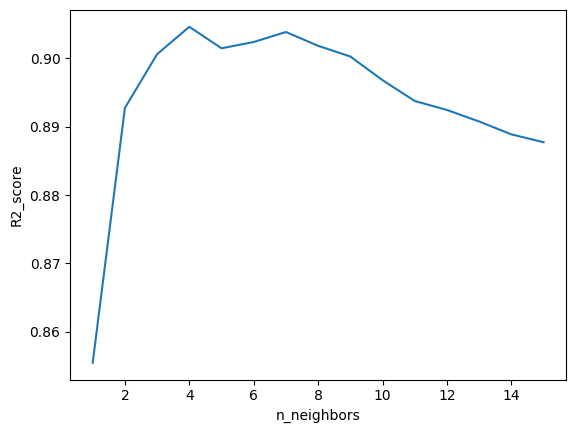

In [47]:
sns.lineplot(x='n_neighbors', y='R2_score', data=result_df)

# As we can see from the graph, we can identify the best k value for our KNN model.
# Choosing this optimal number of neighbors may slightly change the model's performance and improve its predictions.

In [52]:
import pickle

# Save model
with open("knn_model.pkl", "wb") as f:
    pickle.dump(knn, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)